<a href="https://colab.research.google.com/github/BardRimon/Study/blob/main/CV/HW1_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №1

Работу выполнил Клюкин Александр Викторвич
Создание классификатора на основе предобученной модели [efficientnet_b0](https://arxiv.org/abs/1905.11946) для решения задачи классификации карт на основе [датасета cards-image-datasetclassification](https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/code?datasetId=2579480&sortBy=voteCount)  


Уточнение, для работы данного ipynb подразумевается, что вы сначала создаёте ключ (kaggle.json), который кладёте себе в гугл drive, чтобы легко скачивать датасет.

В остальном никаких проблем не должно возникнуть (необходимо иметь все ниже описанные библиотеки версий, что являются актуальными на момент сдачи Лаб1)




## Подготовка данных

### Import files from kaggle
Сначала я подкачиваю личный kaggle.json с ключём из своего диска, чтоб была возможность скачать напрямую в colab

In [ ]:
# Установка kaggle и импорт необходимых модулей
from google.colab import drive
import os

# Монтируем Google Drive в Colab
drive.mount('/content/drive')

# Путь к kaggle.json на Google Drive (укажите путь к своему файлу)
kaggle_json_path = '/content/drive/MyDrive/Colab Notebooks/kaggle.json' ##### ВОТ ТУТ МЕНЯТЬ ПУТЬ К KAGGLE.JSON

# Создаем папку .kaggle в домашней директории и копируем файл туда
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp "{kaggle_json_path}" ~/.kaggle/kaggle.json

# Меняем права доступа к файлу
!chmod 600 ~/.kaggle/kaggle.json

# Проверяем, что всё работает, показывая список датасетов (можно потом заменить командой скачивания)
!kaggle datasets list


Mounted at /content/drive
ref                                                           title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset  Global Earthquake-Tsunami Risk Assessment Dataset       16151  2025-10-01 16:35:53.273000           4545        169  1.0              
jockeroika/life-style-data                                    Life Style Data                                       3995645  2025-10-14 13:50:45.303000           5815        141  0.8235294        
ahmadrazakashif/bmw-worldwide-sales-records-20102024          BMW Worldwide Sales Records (2010–2024)                853348  2025-09-20 14:39:45.280000          10293        228  1.0    

тут указаны основные библиотеки, которые понадобятся

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

для создания датасета из файлов создаю класс на основе класса Dataset из torch

In [ ]:
class PlayingCardDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    @property
    def classes(self):
        return self.data.classes

Собственно скаачиваем зипку датасета

In [ ]:
!kaggle datasets download gpiosenka/cards-image-datasetclassification --force

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
 97% 375M/385M [00:00<00:00, 498MB/s]
100% 385M/385M [00:00<00:00, 567MB/s]


распаковываем зипку в файловую систему

In [ ]:

!unzip -o cards-image-datasetclassification.zip -d cards-image-datasetclassification


Streaming output truncated to the last 5000 lines.
  inflating: cards-image-datasetclassification/train/jack of spades/059.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/060.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/061.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/062.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/063.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/064.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/065.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/066.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/067.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/068.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/069.jpg  
  inflating: cards-image-datasetclassification/train/jack of spades/070.jpg  
  inflating: 

Ну и создаём объект dataset на основе вышеуказанного класса

In [ ]:
dataset = PlayingCardDataset(
    data_dir='cards-image-datasetclassification/train'
)

Размер ИСХОДНОГО датасета

In [ ]:
len(dataset)


7624

сэмпл из датасета

1


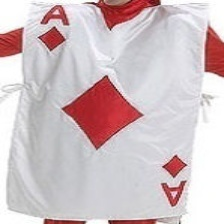

In [ ]:
image, label = dataset[200]
print(label)
image

Традиционно смотрим на датасет перед работой.

для начала посмотрим на типы, которые указаны

In [ ]:
import pandas as pd

df = pd.read_csv('cards-image-datasetclassification/cards.csv')

df.groupby('card type').size()

,0
card type,
ace,642
eight,624
five,622
four,605
jack,711
king,579
nine,580
queen,665
seven,580


In [ ]:
df[df['card type'] == 'jack']

,class index,filepaths,labels,card type,data set
2333,16,train/jack of clubs/001.jpg,jack of clubs,jack,train
2334,16,train/jack of clubs/002.jpg,jack of clubs,jack,train
2335,16,train/jack of clubs/003.jpg,jack of clubs,jack,train
2336,16,train/jack of clubs/004.jpg,jack of clubs,jack,train
2337,16,train/jack of clubs/005.jpg,jack of clubs,jack,train
...,...,...,...,...,...
7985,19,valid/jack of spades/1.jpg,jack of spades,jack,valid
7986,19,valid/jack of spades/2.jpg,jack of spades,jack,valid
7987,19,valid/jack of spades/3.jpg,jack of spades,jack,valid
7988,19,valid/jack of spades/4.jpg,jack of spades,jack,valid


16


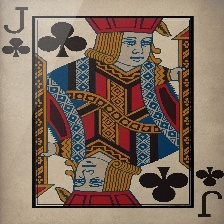

In [ ]:
image, label = dataset[2333]
print(label)
image

Перечисление всех возможных классов (52 карты каждой масти всех номиналов + 1 джокер (label = xxx)

In [ ]:
data_dir='cards-image-datasetclassification/train'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
target_to_class

{0: 'ace of clubs',
 1: 'ace of diamonds',
 2: 'ace of hearts',
 3: 'ace of spades',
 4: 'eight of clubs',
 5: 'eight of diamonds',
 6: 'eight of hearts',
 7: 'eight of spades',
 8: 'five of clubs',
 9: 'five of diamonds',
 10: 'five of hearts',
 11: 'five of spades',
 12: 'four of clubs',
 13: 'four of diamonds',
 14: 'four of hearts',
 15: 'four of spades',
 16: 'jack of clubs',
 17: 'jack of diamonds',
 18: 'jack of hearts',
 19: 'jack of spades',
 20: 'joker',
 21: 'king of clubs',
 22: 'king of diamonds',
 23: 'king of hearts',
 24: 'king of spades',
 25: 'nine of clubs',
 26: 'nine of diamonds',
 27: 'nine of hearts',
 28: 'nine of spades',
 29: 'queen of clubs',
 30: 'queen of diamonds',
 31: 'queen of hearts',
 32: 'queen of spades',
 33: 'seven of clubs',
 34: 'seven of diamonds',
 35: 'seven of hearts',
 36: 'seven of spades',
 37: 'six of clubs',
 38: 'six of diamonds',
 39: 'six of hearts',
 40: 'six of spades',
 41: 'ten of clubs',
 42: 'ten of diamonds',
 43: 'ten of hear

Число классов по итогу 53 (т.к. с джокерами)

### проблема мало данных
Решение - аугментация
будем добавлять (уже в сам объект dataset) исходные сэмплы которые будем немного изменять

Созданим из данных базовый dataset

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

data_dir = 'cards-image-datasetclassification/train'
dataset = PlayingCardDataset(data_dir, transform)

In [ ]:
len(dataset) # у него довольно малая длина

7624

Далее будем увеличивать датасет в несколько раз


Исходя из задания необходимо взять каждого класса от 500 экземпляров,

классов у нас 53, на каждый из них 500 сэмплов и того ~ 53 * 500 = 26500

In [ ]:
target_size = 26500
original_size = len(dataset)
needed_samples = target_size - original_size

# Количество полных наборов данных с аугментацией
num_full_augment_datasets = needed_samples // original_size
# Размер последнего, частичного набора данных
subset_size = needed_samples % original_size

print(f"Необходимо добавить образцов: {needed_samples}")
print(f"Количество полных аугментированных наборов данных для создания: {num_full_augment_datasets}")
print(f"Размер итогового частичного набора: {subset_size}")

# 4. Создаем список наборов данных для объединения
# Начинаем с исходного набора данных
datasets_to_concat = [dataset]


augmentation_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.ToTensor(),
])


# Создаем и добавляем полные аугментированные наборы данных
for _ in range(num_full_augment_datasets):
    augmented_dataset = PlayingCardDataset(data_dir, transform=augmentation_transform)
    datasets_to_concat.append(augmented_dataset)

# Создаем и добавляем частичный набор данных, если необходимо
if subset_size > 0:
    last_augmented_dataset = PlayingCardDataset(data_dir, transform=augmentation_transform)
    # Создаем случайную выборку нужного размера
    indices = np.random.choice(range(len(last_augmented_dataset)), subset_size, replace=False)
    subset_dataset = Subset(last_augmented_dataset, indices)
    datasets_to_concat.append(subset_dataset)

# 5. Объединяем все наборы данных в один
dataset = ConcatDataset(datasets_to_concat)

Необходимо добавить образцов: 0
Количество полных аугментированных наборов данных для создания: 0
Размер итогового частичного набора: 0


In [ ]:
len(dataset)

26500

In [ ]:
image, label = dataset[100]
image.shape

torch.Size([3, 128, 128])

In [ ]:
for image, label in dataset:
    break

In [ ]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
for images, labels in dataloader:
    break

images.shape, labels.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [ ]:
labels

32

## Импорт модели

In [ ]:
class SimpleCardClassifer(nn.Module):
    def __init__(self, num_classes=53):
        super(SimpleCardClassifer, self).__init__()
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(enet_out_size, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        output = self.classifier(x)
        return output

In [ ]:
model = SimpleCardClassifer(num_classes=53)
print(str(model)[:500])

SimpleCardClassifer(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=Fal


In [ ]:
example_out = model(images)
example_out.shape

torch.Size([32, 53])

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
criterion(example_out, labels)
print(example_out.shape, labels.shape)

torch.Size([32, 53]) torch.Size([32])


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_folder = 'cards-image-datasetclassification/train/'
valid_folder = 'cards-image-datasetclassification/valid/'
test_folder = 'cards-image-datasetclassification/test/'

train_dataset = PlayingCardDataset(train_folder, transform=transform)
val_dataset = PlayingCardDataset(valid_folder, transform=transform)
test_dataset = PlayingCardDataset(test_folder, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Обучение

In [ ]:
num_epochs = 5
train_losses, val_losses = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SimpleCardClassifer(num_classes=53)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training loop'):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Valid
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss}, Validation loss: {val_loss}")

Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 - Train loss: 1.5835147588225502, Validation loss: 0.2718582879822209


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 4/5 - Train loss: 0.2361267269955477, Validation loss: 0.18586031805794195


Training loop:   0%|          | 0/239 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/5 - Train loss: 0.19429151401126998, Validation loss: 0.1468867263703976


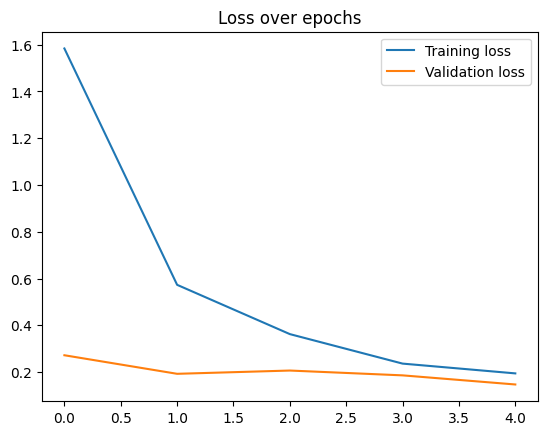

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

In [ ]:
image, label = dataset[100000]
label


5

## Eval

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

def get_predictions_and_labels(model, dataloader, device):

    model.eval()
    all_labels = []

    all_predictions = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    return all_labels, all_predictions


val_labels, val_predictions = get_predictions_and_labels(model, val_loader, device)
class_names = dataset.datasets[0].classes
class_report = classification_report(val_labels, val_predictions, target_names=class_names)
print("\nClassification Report:")
print(class_report)


Classification Report:
                   precision    recall  f1-score   support

     ace of clubs       0.80      0.80      0.80         5
  ace of diamonds       1.00      1.00      1.00         5
    ace of hearts       1.00      1.00      1.00         5
    ace of spades       1.00      1.00      1.00         5
   eight of clubs       0.83      1.00      0.91         5
eight of diamonds       1.00      1.00      1.00         5
  eight of hearts       1.00      1.00      1.00         5
  eight of spades       1.00      1.00      1.00         5
    five of clubs       1.00      1.00      1.00         5
 five of diamonds       1.00      1.00      1.00         5
   five of hearts       1.00      1.00      1.00         5
   five of spades       1.00      1.00      1.00         5
    four of clubs       1.00      0.80      0.89         5
 four of diamonds       1.00      1.00      1.00         5
   four of hearts       1.00      1.00      1.00         5
   four of spades       1.00   

$$ F1 = \frac{2}{\frac1{precision} + \frac1{recall}} $$


## Итог

Мы имеем точность в 96% > 80%, значит поставленная задача - выполнена.